In [1]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("ucimachinelearning/ovarian-ultrasound-image-dataset")

print("Path to dataset files:", path)

100%|██████████| 187M/187M [00:01<00:00, 169MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/ucimachinelearning/ovarian-ultrasound-image-dataset/versions/1


In [2]:
import os

all_classes=os.listdir(os.path.join(path,'Ovarian_US'))

In [3]:
for i in all_classes:
  print(i)

poly_cyst
simple_cyst
dominant_follicle
complex_cyst
healthy


In [4]:
for cl in all_classes:
    full_path = os.path.join(path, 'Ovarian_US', cl)
    print(cl, ':', len(os.listdir(full_path)))

poly_cyst : 1423
simple_cyst : 1326
dominant_follicle : 1297
complex_cyst : 1368
healthy : 1465


In [5]:
#load data
!pip install split-folders

import splitfolders

splitfolders.ratio(
    os.path.join(path, 'Ovarian_US'),
    output="/kaggle/working/Ovarian_US_split",
    seed=42,
    ratio=(0.8, 0.1, 0.1)
)

Copying files: 6879 files [00:01, 5576.62 files/s]


In [6]:
train_dir = "/kaggle/working/Ovarian_US_split/train"
val_dir   = "/kaggle/working/Ovarian_US_split/val"
test_dir  = "/kaggle/working/Ovarian_US_split/test"

In [7]:
len(os.listdir(train_dir))

5

In [8]:
os.listdir(train_dir)

['poly_cyst', 'simple_cyst', 'dominant_follicle', 'complex_cyst', 'healthy']

In [9]:
def distribution_of_data(path):
  classes=os.listdir(path)

  for i in classes:
    updated_path=os.path.join(path,i)

    print(i)
    print(len(os.listdir(updated_path)))

  print("*"*20)
  print()


In [10]:
dirs=[train_dir,val_dir,test_dir]

for i in dirs:
  print(i)
  distribution_of_data(i)

/kaggle/working/Ovarian_US_split/train
poly_cyst
1138
simple_cyst
1060
dominant_follicle
1037
complex_cyst
1094
healthy
1172
********************

/kaggle/working/Ovarian_US_split/val
poly_cyst
142
simple_cyst
132
dominant_follicle
129
complex_cyst
136
healthy
146
********************

/kaggle/working/Ovarian_US_split/test
poly_cyst
143
simple_cyst
134
dominant_follicle
131
complex_cyst
138
healthy
147
********************



In [11]:
#load the data

from tensorflow.keras.preprocessing.image import ImageDataGenerator

img_size = (224, 224)
batch_size = 32

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.1,
    height_shift_range=0.1,
)

val_datagen  = ImageDataGenerator(rescale=1./255)
test_datagen = ImageDataGenerator(rescale=1./255)

train_gen = train_datagen.flow_from_directory(
    "/kaggle/working/Ovarian_US_split/train",
    target_size=img_size,
    batch_size=batch_size,
    class_mode='categorical'
)

val_gen = val_datagen.flow_from_directory(
    "/kaggle/working/Ovarian_US_split/val",
    target_size=img_size,
    batch_size=batch_size,
    class_mode='categorical'
)

test_gen = test_datagen.flow_from_directory(
    "/kaggle/working/Ovarian_US_split/test",
    target_size=img_size,
    batch_size=batch_size,
    class_mode='categorical',
    shuffle=False
)

Found 5498 images belonging to 5 classes.
Found 685 images belonging to 5 classes.
Found 693 images belonging to 5 classes.


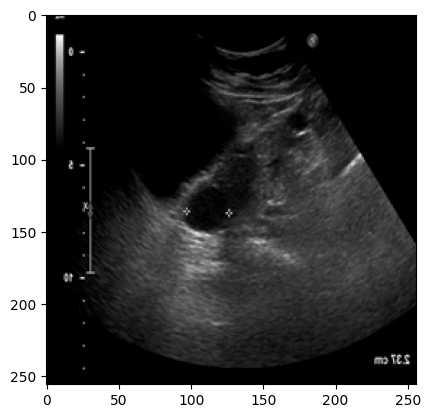

In [12]:
import matplotlib.pyplot as plt
from PIL import Image

first_img=os.listdir(os.path.join(train_dir,'complex_cyst'))[0]

full_img_path=os.path.join(train_dir,'complex_cyst',first_img)

img=Image.open(full_img_path)

plt.imshow(img)
plt.show()

In [13]:
img.mode

'RGB'

In [14]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout

model = Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=(224,224,3)),
    MaxPooling2D(2,2),

    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    Conv2D(128, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(5, activation='softmax')  # 5 classes
])

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

/usr/local/lib/python3.13/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │    11,075,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 5)              │           645 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,169,605 (42.61 MB)

 Trainable params: 11,169,605 (42.61 MB)

 Non-trainable params: 0 (0.00 B)

In [15]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

class_labels = list(train_gen.class_indices.keys())
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(train_gen.classes),
    y=train_gen.classes
)

class_weight_dict = dict(enumerate(class_weights))
print(class_weight_dict)

{0: np.float64(1.0051188299817184), 1: np.float64(1.0613899613899613), 2: np.float64(0.9390264730999146), 3: np.float64(0.9671064204045734), 4: np.float64(1.0373584905660378)}


In [16]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop=EarlyStopping(
    monitor='val_loss',
    mode='min',
    patience=5,
    restore_best_weights=True
)

history = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=50,
    callbacks=[early_stop],
    class_weight=class_weight_dict
)

Epoch 1/50
172/172 ━━━━━━━━━━━━━━━━━━━━ 89s 457ms/step - accuracy: 0.6904 - loss: 0.7082 - val_accuracy: 0.8715 - val_loss: 0.2659
Epoch 2/50
172/172 ━━━━━━━━━━━━━━━━━━━━ 71s 412ms/step - accuracy: 0.8263 - loss: 0.3909 - val_accuracy: 0.8730 - val_loss: 0.2344
Epoch 3/50
172/172 ━━━━━━━━━━━━━━━━━━━━ 70s 405ms/step - accuracy: 0.8556 - loss: 0.3280 - val_accuracy: 0.9387 - val_loss: 0.1619
Epoch 4/50
172/172 ━━━━━━━━━━━━━━━━━━━━ 71s 414ms/step - accuracy: 0.8578 - loss: 0.3145 - val_accuracy: 0.9460 - val_loss: 0.1820
Epoch 5/50
172/172 ━━━━━━━━━━━━━━━━━━━━ 68s 397ms/step - accuracy: 0.8758 - loss: 0.2810 - val_accuracy: 0.9270 - val_loss: 0.1879
Epoch 6/50
172/172 ━━━━━━━━━━━━━━━━━━━━ 69s 400ms/step - accuracy: 0.8874 - loss: 0.2512 - val_accuracy: 0.9445 - val_loss: 0.1940
Epoch 7/50
172/172 ━━━━━━━━━━━━━━━━━━━━ 71s 411ms/step - accuracy: 0.9023 - loss: 0.2360 - val_accuracy: 0.9445 - val_loss: 0.1732
Epoch 8/50
172/172 ━━━━━━━━━━━━━━━━━━━━ 68s 398ms/step - accuracy: 0.9058 - loss: 0

In [17]:
test_loss, test_acc = model.evaluate(test_gen)
print("Test Accuracy:", test_acc)

22/22 ━━━━━━━━━━━━━━━━━━━━ 4s 189ms/step - accuracy: 0.9336 - loss: 0.1635
Test Accuracy: 0.9336219429969788


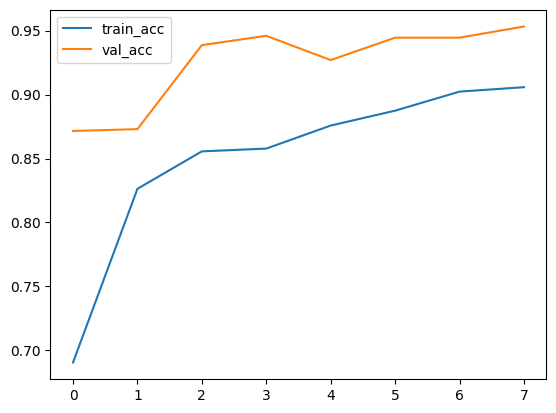

In [18]:
plt.plot(history.history['accuracy'], label='train_acc')
plt.plot(history.history['val_accuracy'], label='val_acc')
plt.legend()
plt.show()

In [19]:
from sklearn.metrics import classification_report
import numpy as np

# get true labels
y_true = test_gen.classes

# get predictions
y_pred_probs = model.predict(test_gen)
y_pred = np.argmax(y_pred_probs, axis=1)

# class names
class_labels = list(test_gen.class_indices.keys())

print(classification_report(y_true, y_pred, target_names=class_labels))

22/22 ━━━━━━━━━━━━━━━━━━━━ 5s 128ms/step
                   precision    recall  f1-score   support

     complex_cyst       0.82      0.88      0.85       138
dominant_follicle       0.98      1.00      0.99       131
          healthy       1.00      1.00      1.00       147
        poly_cyst       1.00      1.00      1.00       143
      simple_cyst       0.87      0.78      0.82       134

         accuracy                           0.93       693
        macro avg       0.93      0.93      0.93       693
     weighted avg       0.93      0.93      0.93       693



In [20]:
from tensorflow.keras.applications.vgg16 import preprocess_input as vgg_pre
from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import VGG16
from tensorflow.keras.models import Sequential
from tensorflow.keras.callbacks import EarlyStopping
import tensorflow as tf

IMG_SIZE = 224
BATCH_SIZE = 32

train_dir = "/kaggle/working/Ovarian_US_split/train"
val_dir   = "/kaggle/working/Ovarian_US_split/val"
test_dir  = "/kaggle/working/Ovarian_US_split/test"

# generators for VGG16 (no rescale, use vgg_pre instead)
train_datagen = ImageDataGenerator(
    preprocessing_function=vgg_pre,
    width_shift_range=0.05, height_shift_range=0.05,
    fill_mode='constant', cval=0
)

val_datagen  = ImageDataGenerator(preprocessing_function=vgg_pre)
test_datagen = ImageDataGenerator(preprocessing_function=vgg_pre)

train_ds = train_datagen.flow_from_directory(
    train_dir, target_size=(IMG_SIZE, IMG_SIZE), color_mode='rgb',
    class_mode='categorical', batch_size=BATCH_SIZE, shuffle=True, seed=42
)

val_ds = val_datagen.flow_from_directory(
    val_dir, target_size=(IMG_SIZE, IMG_SIZE), color_mode='rgb',
    class_mode='categorical', batch_size=BATCH_SIZE, shuffle=False
)

test_ds = test_datagen.flow_from_directory(
    test_dir, target_size=(IMG_SIZE, IMG_SIZE), color_mode='rgb',
    class_mode='categorical', batch_size=BATCH_SIZE, shuffle=False
)

# sanity check: VGG range should be roughly -120 to +150, NOT 0 to 1
x, y = next(train_ds)
print(x.min(), x.max())

# build model
vgg_base = VGG16(weights='imagenet', include_top=False, input_shape=(IMG_SIZE, IMG_SIZE, 3))
vgg_base.trainable = False   # freeze first

vgg_model = Sequential([
    vgg_base,
    GlobalAveragePooling2D(),
    Dense(128, activation='relu'),
    Dropout(0.4),
    Dense(5, activation='softmax')
])

vgg_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy',
             tf.keras.metrics.Precision(name='precision'),
             tf.keras.metrics.Recall(name='recall')]
)

early = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

vgg_history = vgg_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=30,
    callbacks=[early],
    class_weight=class_weight_dict
)

Found 5498 images belonging to 5 classes.
Found 685 images belonging to 5 classes.
Found 693 images belonging to 5 classes.
-123.68 151.061
58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/30
172/172 ━━━━━━━━━━━━━━━━━━━━ 119s 580ms/step - accuracy: 0.8574 - loss: 0.4546 - precision: 0.8664 - recall: 0.8527 - val_accuracy: 0.9635 - val_loss: 0.1048 - val_precision: 0.9635 - val_recall: 0.9635
Epoch 2/30
172/172 ━━━━━━━━━━━━━━━━━━━━ 80s 464ms/step - accuracy: 0.9442 - loss: 0.1317 - precision: 0.9453 - recall: 0.9429 - val_accuracy: 0.9737 - val_loss: 0.0700 - val_precision: 0.9737 - val_recall: 0.9737
Epoch 3/30
172/172 ━━━━━━━━━━━━━━━━━━━━ 79s 462ms/step - accuracy: 0.9611 - loss: 0.0954 - precision: 0.9623 - recall: 0.9611 - val_accuracy: 0.9869 - val_loss: 0.0442 - val_precision: 0.9869 - val_recall: 0.9869
Epoch 4/30
172/172 ━━━━━━━━━━━━━━━━━━━━ 83s 480ms/step - accuracy: 0.9765 - loss: 0.0637 - precision: 0.9769 - recall: 0.9756 - val_accuracy: 0.9912 - val_loss: 0.0274 -

In [21]:
test_loss, test_acc, test_prec, test_rec = vgg_model.evaluate(test_ds)
print("Test Accuracy:", test_acc)

y_pred_probs = vgg_model.predict(test_ds)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = test_ds.classes
class_labels = list(test_ds.class_indices.keys())

from sklearn.metrics import classification_report
print(classification_report(y_true, y_pred, target_names=class_labels))

22/22 ━━━━━━━━━━━━━━━━━━━━ 15s 695ms/step - accuracy: 0.9986 - loss: 0.0042 - precision: 0.9986 - recall: 0.9986
Test Accuracy: 0.9985569715499878
22/22 ━━━━━━━━━━━━━━━━━━━━ 5s 186ms/step
                   precision    recall  f1-score   support

     complex_cyst       1.00      0.99      1.00       138
dominant_follicle       1.00      1.00      1.00       131
          healthy       1.00      1.00      1.00       147
        poly_cyst       1.00      1.00      1.00       143
      simple_cyst       0.99      1.00      1.00       134

         accuracy                           1.00       693
        macro avg       1.00      1.00      1.00       693
     weighted avg       1.00      1.00      1.00       693



In [22]:
vgg_model.save('/kaggle/working/ovarian_vgg16_model.h5')

In [24]:
from google.colab import files
files.download('/kaggle/working/ovarian_vgg16_model.h5')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step


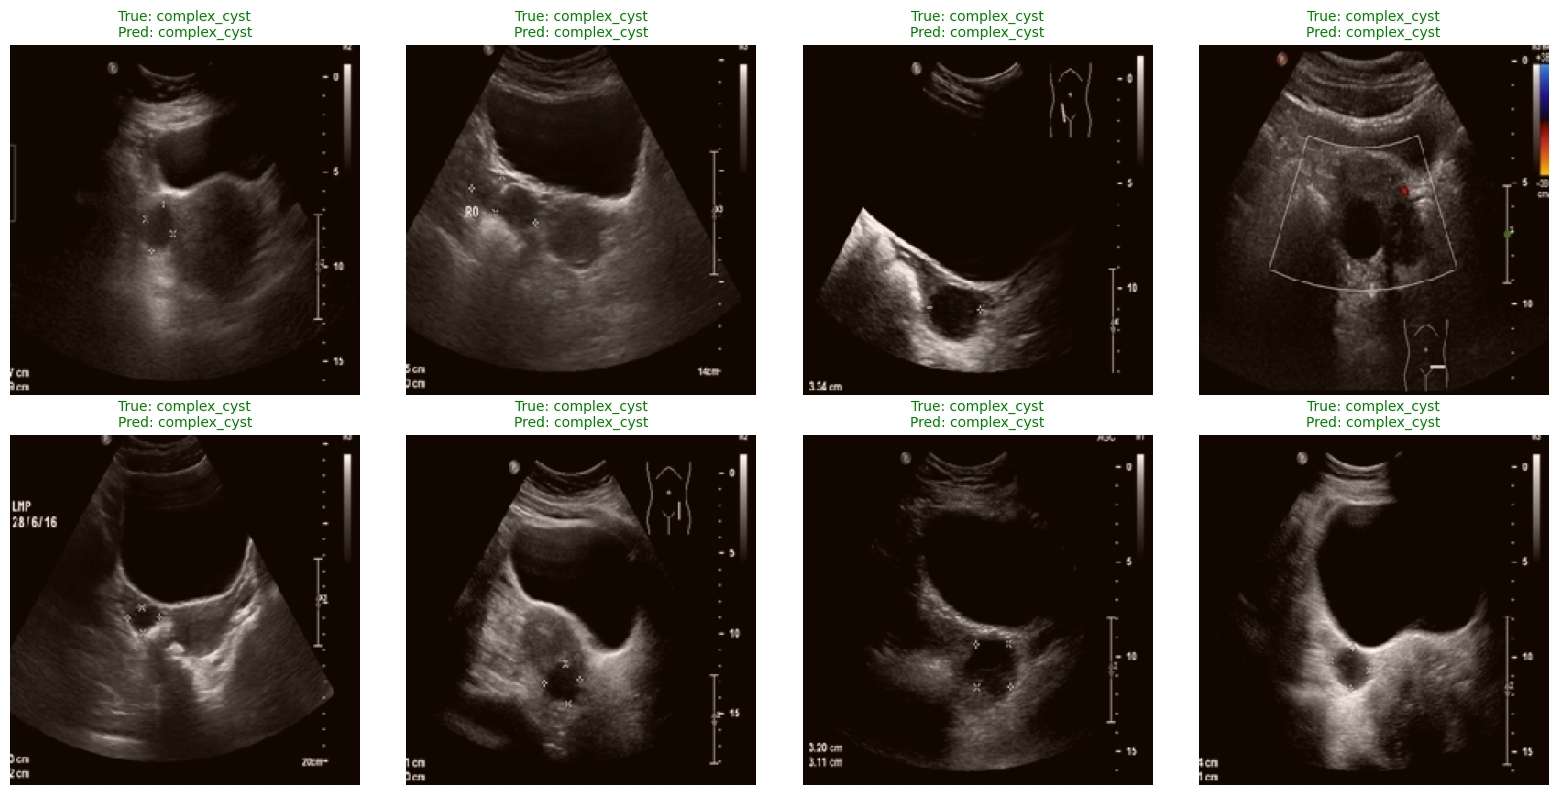

In [25]:
import matplotlib.pyplot as plt
import numpy as np

# get a batch of test images
x_batch, y_batch = next(test_ds)

# predict on this batch
preds = vgg_model.predict(x_batch)
pred_labels = np.argmax(preds, axis=1)
true_labels = np.argmax(y_batch, axis=1)

class_labels = list(test_ds.class_indices.keys())

# plot
n = 8  # number of images to show
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

for i in range(n):
    img = x_batch[i]
    # undo VGG preprocessing for display (approx, just for visualization)
    img_display = img - img.min()
    img_display = img_display / img_display.max()

    axes[i].imshow(img_display)
    true_cls = class_labels[true_labels[i]]
    pred_cls = class_labels[pred_labels[i]]
    color = 'green' if true_cls == pred_cls else 'red'
    axes[i].set_title(f"True: {true_cls}\nPred: {pred_cls}", color=color, fontsize=10)
    axes[i].axis('off')

plt.tight_layout()
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step


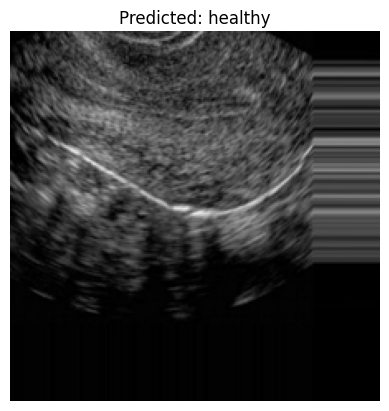

In [35]:
img_path = "/content/h1.jpg"

img = Image.open(img_path).convert('RGB').resize((224, 224))
img_array = np.array(img)
img_array = np.expand_dims(img_array, axis=0)
img_array = vgg_pre(img_array)

pred = vgg_model.predict(img_array)
pred_class = class_labels[np.argmax(pred)]

plt.imshow(img)
plt.title(f"Predicted: {pred_class}")
plt.axis('off')
plt.show()

In [36]:
for cls, prob in zip(class_labels, pred[0]):
    print(f"{cls}: {prob:.4f}")

complex_cyst: 0.0000
dominant_follicle: 0.0000
healthy: 1.0000
poly_cyst: 0.0000
simple_cyst: 0.0000
